# Phase 3: Quality Check

**Метод:** Сравниваем авто-разметку (rubert-tiny2) с keyword-based heuristic аннотатором.  
**Метрика:** Cohen's κ — inter-annotator agreement.  
**Данные:** `data/labeled/strategy_a_labeled.csv`

In [1]:
import sys
sys.path.append('../src')

import csv
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

LABELED_PATH = '../data/labeled/strategy_a_labeled.csv'
REPORT_PATH  = '../data/reports/quality_metrics.json'

print('OK')

OK


## 1. Load labeled data

In [2]:
with open(LABELED_PATH, encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

df = pd.DataFrame(rows)
df['confidence'] = df['confidence'].astype(float)
print(f'Loaded {len(df)} rows')
print(df['label'].value_counts())

Loaded 807 rows
label
liked        464
mixed        296
not_liked     47
Name: count, dtype: int64


## 2. Keyword-based annotator (second annotator for agreement)

In [3]:
LIKED_KEYWORDS = [
    'нравится', 'понравился', 'понравилась', 'обожаю', 'люблю', 'отличный',
    'отличная', 'шедевр', 'рекомендую', 'куплю', 'прекрасный', 'прекрасно',
    'великолепный', 'восхитительный', 'обожать', 'моя любовь', 'буду брать',
    'стал фаворитом', 'в коллекцию', 'мой любимый', 'замечательный',
    'потрясающий', 'потрясающе', 'лучший', 'лучшее', 'блестящий', 'кайф',
    'кайфую', 'офигенный', 'топ', 'супер', 'классный', 'шикарный',
]

NOT_LIKED_KEYWORDS = [
    'не понравился', 'не понравилась', 'не нравится', 'отвратительный',
    'отвратительно', 'ужасный', 'ужасно', 'продал', 'продала', 'вернул',
    'вернула', 'невыносимо', 'невыносимый', 'не куплю', 'не возьму',
    'не рекомендую', 'разочарован', 'разочарована', 'пожалел', 'пожалела',
    'не для меня', 'не моё', 'мерзко', 'мерзкий', 'воняет', 'вонь',
    'тошнит', 'тошнота', 'плохо', 'кошмар', 'кошмарный', 'дикость',
]

def keyword_label(text: str) -> str:
    text_low = text.lower()
    liked_score = sum(1 for kw in LIKED_KEYWORDS if kw in text_low)
    not_liked_score = sum(1 for kw in NOT_LIKED_KEYWORDS if kw in text_low)
    
    if liked_score == 0 and not_liked_score == 0:
        return 'mixed'
    if not_liked_score > liked_score:
        return 'not_liked'
    if liked_score > not_liked_score:
        return 'liked'
    return 'mixed'  # tie

df['kw_label'] = df['review_text'].apply(keyword_label)
print('Keyword annotator distribution:')
print(df['kw_label'].value_counts())

Keyword annotator distribution:
kw_label
mixed        464
liked        281
not_liked     62
Name: count, dtype: int64


## 3. Cohen's κ

In [4]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

y_model = df['label'].values
y_kw    = df['kw_label'].values

kappa = cohen_kappa_score(y_model, y_kw)
agreement_pct = (y_model == y_kw).mean() * 100

def interpret_kappa(k):
    if k < 0:    return 'Poor (worse than chance)'
    if k < 0.20: return 'Slight'
    if k < 0.40: return 'Fair'
    if k < 0.60: return 'Moderate'
    if k < 0.80: return 'Substantial'
    return 'Almost perfect'

print(f"Cohen's κ     : {kappa:.4f} ({interpret_kappa(kappa)})")
print(f"% Agreement   : {agreement_pct:.1f}%")
print()
print('Classification report (model vs keyword):')
labels = ['liked', 'mixed', 'not_liked']
print(classification_report(y_model, y_kw, labels=labels))

Cohen's κ     : 0.2367 (Fair)
% Agreement   : 55.4%

Classification report (model vs keyword):
              precision    recall  f1-score   support

       liked       0.78      0.47      0.59       464
       mixed       0.46      0.73      0.57       296
   not_liked       0.21      0.28      0.24        47

    accuracy                           0.55       807
   macro avg       0.48      0.49      0.46       807
weighted avg       0.63      0.55      0.56       807



## 4. Confusion matrix

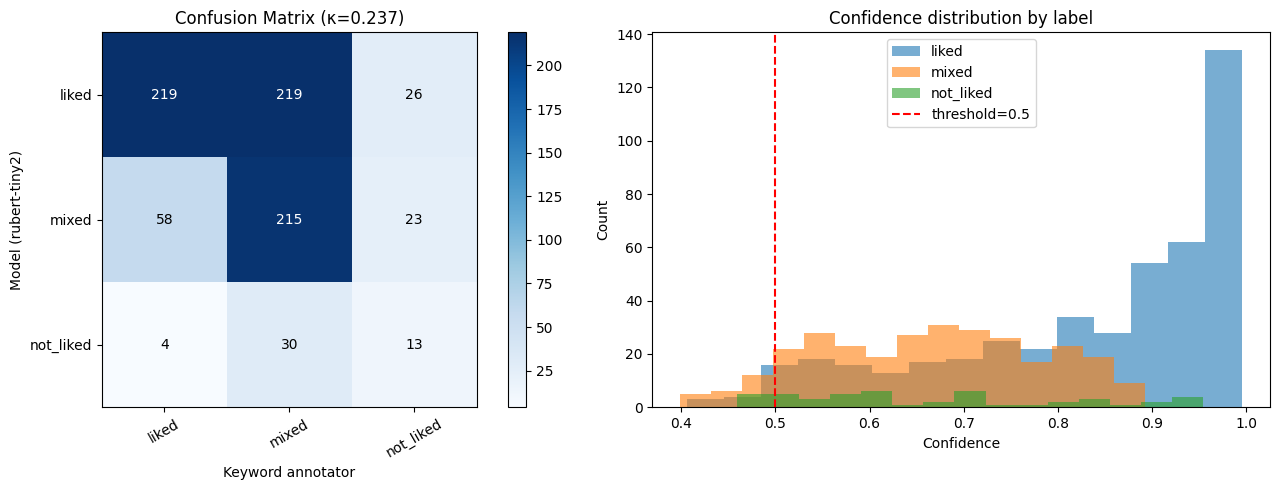

In [5]:
labels = ['liked', 'mixed', 'not_liked']
cm = confusion_matrix(y_model, y_kw, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=30)
axes[0].set_yticklabels(labels)
axes[0].set_xlabel('Keyword annotator')
axes[0].set_ylabel('Model (rubert-tiny2)')
axes[0].set_title(f"Confusion Matrix (κ={kappa:.3f})")
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

# Confidence by label
for label in labels:
    subset = df[df['label'] == label]['confidence']
    axes[1].hist(subset, bins=15, alpha=0.6, label=label)
axes[1].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
axes[1].set_title('Confidence distribution by label')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/reports/quality_check.png', dpi=100)
plt.show()

## 5. Disagreement analysis

In [6]:
disagree = df[df['label'] != df['kw_label']].copy()
print(f'Disagreements: {len(disagree)} / {len(df)} ({len(disagree)/len(df)*100:.1f}%)')
print()
print('Disagreement patterns:')
print(disagree.groupby(['label', 'kw_label']).size().sort_values(ascending=False).head(10))
print()
print('Sample disagreements (model=mixed, kw=liked):')
sample = disagree[(disagree['label']=='mixed') & (disagree['kw_label']=='liked')].head(3)
for _, row in sample.iterrows():
    print(f'  [{row["confidence"]:.2f}] {row["perfume_name"]}')
    print(f'  {row["review_text"][:200]}')
    print()

Disagreements: 360 / 807 (44.6%)

Disagreement patterns:
label      kw_label 
liked      mixed        219
mixed      liked         58
not_liked  mixed         30
liked      not_liked     26
mixed      not_liked     23
not_liked  liked          4
dtype: int64

Sample disagreements (model=mixed, kw=liked):
  [0.49] Chanel No 5 Eau de Parfum
  Как любая классика, этот парфюм неизвестен большинству людей и вообще сколь либо пользователям парфюмерии. Ты знаешь его название, знаешь просто это "слово", на том и достаточно... Может быть раз - дв

  [0.59] Cuoium
  С кожаными ароматами тосканского направления мне не повезло - не люблю сочетание кожи и малины. Поэтому ищу другие профили. В куоюме кожа анималистична, прокурена сигаретным дымом, присыпана землей, о

  [0.40] Cuoium
  Немного об этом чуде от Гуалтьери-брутален! Это как жрать ржавые гвозди и чесать спину рельсой. Итак, нанёс я на запястье Orto Parisi Cuoium, Стою обоняю, в ожидании чуда... И тут одна губастая гопниц



## 6. Label distribution comparison

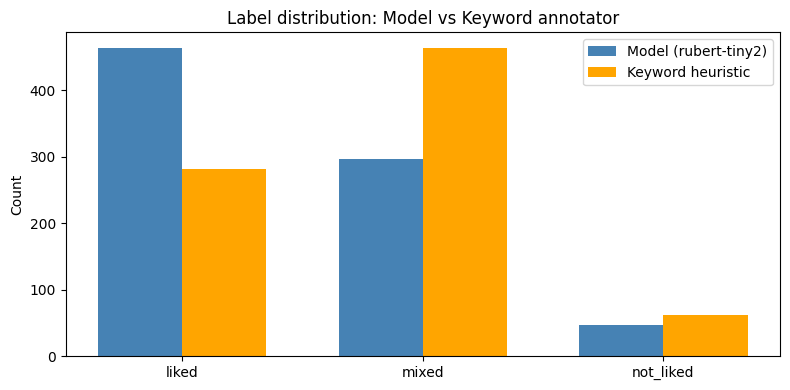

In [7]:
labels = ['liked', 'mixed', 'not_liked']
model_counts = [df['label'].value_counts().get(l, 0) for l in labels]
kw_counts    = [df['kw_label'].value_counts().get(l, 0) for l in labels]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, model_counts, width, label='Model (rubert-tiny2)', color='steelblue')
ax.bar(x + width/2, kw_counts,    width, label='Keyword heuristic',    color='orange')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Label distribution: Model vs Keyword annotator')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../data/reports/distribution_comparison.png', dpi=100)
plt.show()

## 7. Save updated quality report

In [8]:
with open(REPORT_PATH, encoding='utf-8') as f:
    report = json.load(f)

report['cohen_kappa'] = round(kappa, 4)
report['kappa_interpretation'] = interpret_kappa(kappa)
report['agreement_pct'] = round(agreement_pct, 1)
report['disagreements'] = int(len(disagree))
report['second_annotator'] = 'keyword-heuristic'

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(json.dumps(report, ensure_ascii=False, indent=2))

{
  "total": 807,
  "labeled": 807,
  "mean_confidence": 0.7625,
  "uncertain_count": 44,
  "uncertain_pct": 5.5,
  "distribution": {
    "mixed": {
      "count": 296,
      "pct": 36.7
    },
    "liked": {
      "count": 464,
      "pct": 57.5
    },
    "not_liked": {
      "count": 47,
      "pct": 5.8
    }
  },
  "cohen_kappa": 0.2367,
  "kappa_interpretation": "Fair",
  "agreement_pct": 55.4,
  "disagreements": 360,
  "second_annotator": "keyword-heuristic"
}


## Summary

In [9]:
print('═' * 47)
print('📋 ФАЗА 3: QUALITY CHECK — ЗАВЕРШЕНА')
print('═' * 47)
print(f"Cohen's κ      : {kappa:.4f} ({interpret_kappa(kappa)})")
print(f"% Agreement    : {agreement_pct:.1f}%")
print(f"Disagreements  : {len(disagree)}")
model_dist = df['label'].value_counts()
for l in ['liked','mixed','not_liked']:
    n = model_dist.get(l, 0)
    print(f"  {l:12s}: {n} ({n/len(df)*100:.1f}%)")
print('═' * 47)

═══════════════════════════════════════════════
📋 ФАЗА 3: QUALITY CHECK — ЗАВЕРШЕНА
═══════════════════════════════════════════════
Cohen's κ      : 0.2367 (Fair)
% Agreement    : 55.4%
Disagreements  : 360
  liked       : 464 (57.5%)
  mixed       : 296 (36.7%)
  not_liked   : 47 (5.8%)
═══════════════════════════════════════════════
